<a href="https://colab.research.google.com/github/gayakarapetyan/PythonCourseH2/blob/main/Session3/01_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression
**Environmental Statistics and Artificial Intelligence — Practical Block 3, Part 1**

**Data for today** the CAMELS-DE catchment attributes: 1,582 German river catchments, each described
by topography, climate, land cover, soil, and hydrological behaviour. One row = one catchment.

You can download full data from https://zenodo.org/records/13837553

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

np.random.seed(42)
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 90

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# chang the path
DATA = "/content/drive/MyDrive/Colab Notebooks/PythonCourse/Session3/Data/teaching_data/camels_de_attributes_teaching.csv"

df = pd.read_csv(DATA)
print(df.shape)
df.head(3)

(1582, 20)


,gauge_id,area,elev_mean,slope_mean,p_mean,p_seasonality,frac_snow,aridity,forest_frac,agriculture_frac,artificial_frac,clay_frac,sand_frac,dams_num,q_mean,runoff_ratio,baseflow_index,high_q_freq,slope_fdc,hfd_mean
0,DE710000,43.2,272.0,34.2,2.360,0.077,0.242,1.339,0.439,0.379,0.080,23.7,39.1,1,1.339,0.567,0.658,10.66,2.566,200.0
1,DE210001,34.7,560.0,17.7,2.548,0.176,0.383,1.293,0.352,0.349,0.213,21.1,41.8,0,1.504,0.558,0.801,4.94,2.200,176.0
2,DE110002,866.1,50.0,30.8,1.350,0.201,0.103,1.775,0.010,0.667,0.211,16.0,25.3,2,0.639,0.409,0.517,17.55,1.471,149.0


**Meet the columns** (units in brackets):

| Group | Columns |
|---|---|
| Topography | `area` [km²], `elev_mean` [m], `slope_mean` [m/km] |
| Climate | `p_mean` [mm/d], `p_seasonality` [–], `frac_snow` [–], `aridity` [PET/P, –] |
| Land cover | `forest_frac`, `agriculture_frac`, `artificial_frac` [fractions 0–1] |
| Soil | `clay_frac`, `sand_frac` [%] |
| Human influence | `dams_num` [count] |
| **Hydrologic signatures** | `q_mean` [mm/d], `runoff_ratio` [–], `baseflow_index` [–], `high_q_freq` [d/yr], `slope_fdc` [–], `hfd_mean` [day of year] |


In [ ]:
df.describe().round(2)

,area,elev_mean,slope_mean,p_mean,p_seasonality,frac_snow,aridity,forest_frac,agriculture_frac,artificial_frac,clay_frac,sand_frac,dams_num,q_mean,runoff_ratio,baseflow_index,high_q_freq,slope_fdc,hfd_mean
count,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00,1582.00
mean,351.53,364.05,11.70,2.23,0.19,0.25,1.58,0.33,0.43,0.17,20.68,38.01,0.44,1.04,0.44,0.70,8.23,2.02,196.10
std,641.72,301.67,11.14,0.71,0.13,0.14,0.32,0.19,0.20,0.06,6.34,10.59,0.81,0.61,0.12,0.11,4.12,0.73,31.84
min,5.00,15.00,0.50,1.20,-0.18,0.00,0.45,0.01,0.00,0.00,4.00,8.00,0.00,0.19,0.14,0.37,0.50,0.40,100.00
25%,57.52,131.00,0.50,1.71,0.10,0.14,1.38,0.20,0.30,0.12,16.40,30.62,0.00,0.61,0.35,0.63,5.20,1.53,174.25
50%,150.05,298.50,9.60,2.10,0.20,0.26,1.61,0.32,0.44,0.17,20.50,38.20,0.00,0.85,0.42,0.70,8.14,2.03,196.00
75%,376.40,496.75,18.60,2.62,0.28,0.36,1.80,0.46,0.58,0.21,24.90,45.40,1.00,1.26,0.50,0.78,11.10,2.50,218.00
max,12617.20,1281.00,55.40,4.61,0.60,0.52,2.52,0.97,0.84,0.31,43.50,71.20,5.00,4.13,0.95,0.97,23.98,4.31,287.00


---
# Part A — Characterizing the data

Before computing *any* statistic, **look at the data**. A scatter plot shows the *joint*
behaviour of two variables — every structure, cluster, outlier, or non-linearity is visible
here and *invisible* in summary numbers.

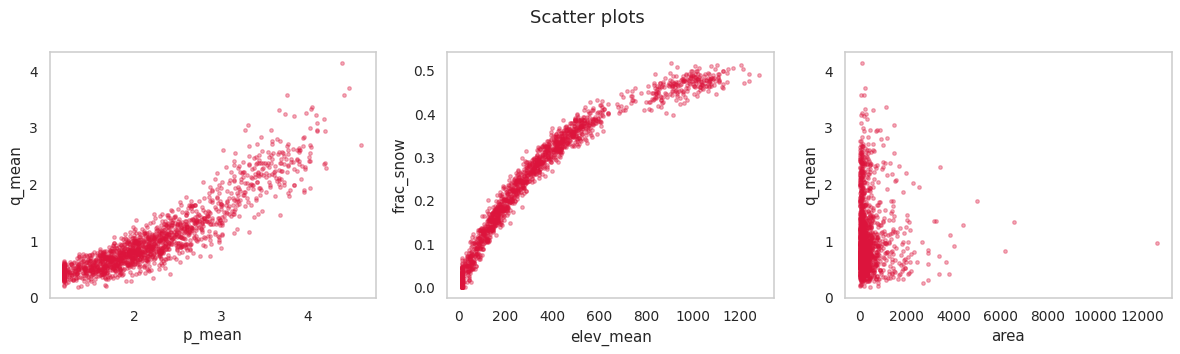

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

pairs = [("p_mean", "q_mean"), ("elev_mean", "frac_snow"), ("area", "q_mean")]
for ax, (xv, yv) in zip(axes, pairs):
    ax.scatter(df[xv], df[yv], s=8, alpha=0.35, color="crimson")
    ax.set_xlabel(xv); ax.set_ylabel(yv)
    ax.grid(False)
plt.suptitle("Scatter plots")
plt.tight_layout()
plt.show()

**Discussion**
- `p_mean → q_mean`: clear positive, roughly linear relationship (more rain → more discharge).
- `elev_mean → frac_snow`: positive, but *curved* — snow fraction saturates. Non-linear!
- `area → q_mean`: …a mess? Most catchments are small; a few are huge. The x-axis is dominated *by* them.

## Joint, marginal, and conditional probability

A scatter plot is the picture of the **joint distribution** $P(X, Y)$ — how probable is it to
find a catchment with *this* x **and** *that* y at the same time?

From the joint distribution we can derive two further views:

- **Marginal** $P(X)$: the distribution of one variable, *ignoring* the other
  (collapse / project the cloud onto one axis).
- **Conditional** $P(Y \mid X = x)$: the distribution of $Y$ *given that* $X$ has a particular
  value (a vertical slice through the cloud).

Seaborn's `jointplot` shows the joint distribution in the middle and both marginals on the sides:

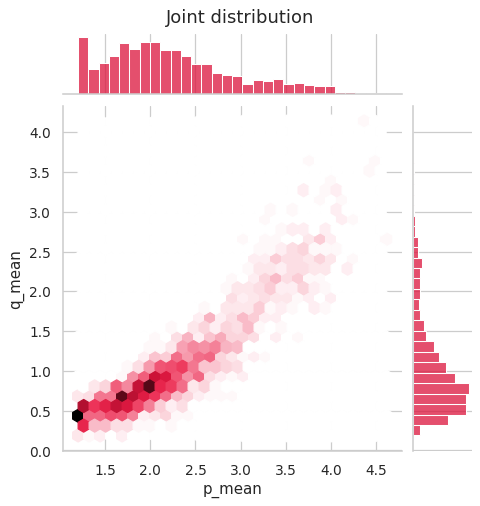

In [ ]:
sns.jointplot(data=df, x="p_mean", y="q_mean", kind="hex",
              height=5.5, color="crimson", marginal_kws=dict(bins=30))
plt.suptitle("Joint distribution", y=1.02)
plt.show()

## Covariance and Pearson correlation

For two **numeric** variables we summarize *linear* co-variation:

$$\mathrm{cov}(X,Y) = \frac{1}{n-1}\sum_i (x_i-\bar x)(y_i - \bar y)$$

Positive: when x is above its mean, y tends to be above its mean too. The problem:
covariance has units (mm/d × mm/d…) and its size is not interpretable. So we standardize it:

$$r = \frac{\mathrm{cov}(X,Y)}{s_X \, s_Y} \in [-1, 1] \qquad \text{(Pearson correlation)}$$

- $r = +1$: perfect increasing **line** · $r = -1$: perfect decreasing line · $r = 0$: no **linear** relation
- $r^2$ = fraction of variance of one variable linearly explained by the other (preview of R²!)

In [ ]:
x, y = df["p_mean"], df["q_mean"]
print("covariance:", np.cov(x, y)[0, 1].round(4))
r, p = stats.pearsonr(x, y)
print(f"Pearson r: {r:.3f}   (p = {p:.1f})")
print(f"r²: {r**2:.3f}  ← {100*r**2:.0f}% of q_mean variance is 'linearly shared' with p_mean")

covariance: 0.3986
Pearson r: 0.913   (p = 0.0)
r²: 0.833  ← 83% of q_mean variance is 'linearly shared' with p_mean


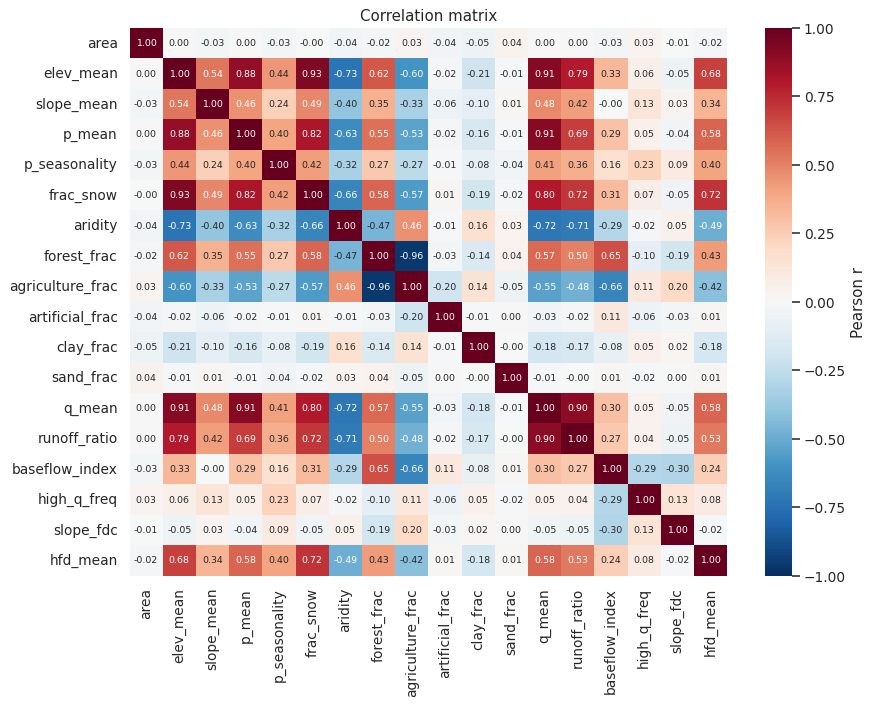

In [ ]:
# The correlation matrix as we know from prev class
num = df.select_dtypes("number").drop(columns=["dams_num"])
corr = num.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7.5},
            cbar_kws={"label": "Pearson r"})
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

Minitask
**Spend 2 minutes reading this map.** Find:

---
the strongest correlations with `q_mean` (our main target),



## Spearman correlation

**Spearman's ρ** = Pearson correlation of the **ranks** of the data. It asks: *when x increases,
does y tend to increase* regardless of shape?

In [ ]:
# elevation vs snow fraction: curved (saturating) but monotonic
r_p, _ = stats.pearsonr(df["elev_mean"], df["frac_snow"])
r_s, _ = stats.spearmanr(df["elev_mean"], df["frac_snow"])
print(f"elev_mean vs frac_snow:   Pearson r = {r_p:.3f}   Spearman rho = {r_s:.3f}")

# area vs q_mean: dominated by a few huge catchments (skew!)
r_p2, _ = stats.pearsonr(df["area"], df["q_mean"])
r_s2, _ = stats.spearmanr(df["area"], df["q_mean"])
print(f"area      vs q_mean   :   Pearson r = {r_p2:.3f}   Spearman rho = {r_s2:.3f}")

elev_mean vs frac_snow:   Pearson r = 0.933   Spearman rho = 0.991
area      vs q_mean   :   Pearson r = 0.002   Spearman rho = -0.002


---
# Part B — Building regression models

In Part A we learned to *measure* a relationship. Now we *model* it: build something that takes a
catchment's properties and **predicts** its discharge.



## B1. Set up the data

Let's predict **discharge (`q_mean`)** from **precipitation (`p_mean`)

We split the catchments into a **training set** (the model learns from these) and a **test set**
(kept hidden, used only to check how well the model predicts catchments it has never seen).


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = df[["p_mean"]]  # features: 2-D (double brackets!) — but we use one column for now
y = df["q_mean"]    # target: 1-D what we predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)    # 70% train, 30% test

print("training catchments:", len(X_train))
print("test catchments    :", len(X_test))

training catchments: 1107
test catchments    : 475


## B2. Parametric regression

A **parametric** model assumes the relationship has a fixed *shape* and just finds the best version
of that shape. The simplest shape is a straight line:

> discharge = slope × precipitation + intercept

This is **linear regression**. scikit-learn fits it with `LinearRegression`. The method it uses to
find the best line is called **OLS — Ordinary Least Squares**: it picks the line that makes the
prediction errors (the vertical gaps between the points and the line) as small as possible, by
minimizing the *squared* errors.

In [ ]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X_train, y_train)

print(f"slope = {linear.coef_[0]:.3f}")
print(f"intercept = {linear.intercept_:.3f}")
print(f"R² on test set = {linear.score(X_test, y_test):.3f}")

slope = 0.789
intercept = -0.725
R² on test set = 0.825


**Description**
- the **slope** tells you how much discharge increases for each extra unit of precipitation,
- **R²** (on the test set) is the fraction of discharge variation the model explains


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


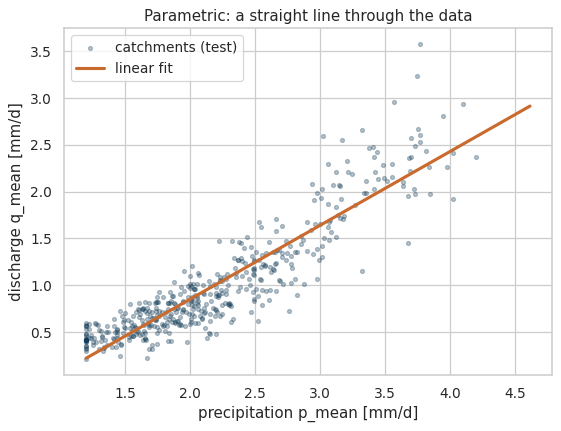

In [ ]:
import numpy as np

# a smooth range of precipitation values, to draw the model's line
x_line = np.linspace(df["p_mean"].min(), df["p_mean"].max(), 200).reshape(-1, 1)

plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, s=10, alpha=0.3, color="#143d59", label="catchments (test)")
plt.plot(x_line, linear.predict(x_line), color="#c96a2e", lw=2.5, label="linear fit")
plt.xlabel("precipitation p_mean [mm/d]"); plt.ylabel("discharge q_mean [mm/d]")
plt.legend(); plt.title("Parametric: a straight line through the data")
plt.show()

In [ ]:
#How well the model worked
# predict discharge for every test catchment
predicted = linear.predict(X_test)

# put actual vs predicted side by side
check = pd.DataFrame({
    "actual_q_mean":    y_test.values,
    "predicted_q_mean": predicted,
})
check["error"] = (check["predicted_q_mean"] - check["actual_q_mean"]).round(2)
check = check.round(2)

print(check.head(8).to_string(index=False))
print()
mae = abs(predicted - y_test.values).mean()
print(f"On average the prediction is off by {mae:.2f} mm/d (mean absolute error)")

 actual_q_mean  predicted_q_mean  error
          2.46              1.94  -0.53
          0.59              0.24  -0.35
          0.76              0.78   0.02
          0.80              0.95   0.15
          2.03              1.97  -0.06
          0.43              0.58   0.15
          0.62              1.26   0.65
          0.89              0.74  -0.15

On average the prediction is off by 0.19 mm/d (mean absolute error)


### Task 1
Use `linear.predict(...)` to predict the discharge of a catchment with `p_mean = 3.0` mm/d.
(Hint: the input must be 2-D.)

In [ ]:
# Your code here


## B3. Non-parametric regression

A **non-parametric** model makes *no* assumption about the shape. It lets the data dictate the
curve, so it can bend to follow whatever pattern is there. It's more
flexible but less interpretable, and it needs more data.



**k-Nearest Neighbours (KNN):** to predict a catchment's discharge, it averages the discharge of
the *k* most similar catchments (here, those with the closest precipitation). `n_neighbors` is *k*.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=20)     # only this line differs from linear regression!
knn.fit(X_train, y_train)
print(f"KNN  R² on test set = {knn.score(X_test, y_test):.3f}")

KNN  R² on test set = 0.840


**Random Forest:** averages many decision trees. It's a popular, powerful non-parametric model
that handles curves and interactions automatically.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators=200, random_state=0)
forest.fit(X_train, y_train)
print(f"Random Forest  R² on test set = {forest.score(X_test, y_test):.3f}")

Random Forest  R² on test set = 0.788


Now let's plot all three models together

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


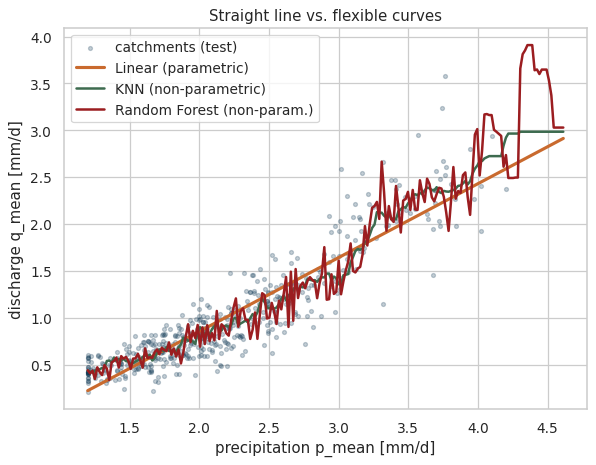

In [ ]:
x_line = np.linspace(df["p_mean"].min(), df["p_mean"].max(), 200).reshape(-1, 1)

plt.figure(figsize=(7.5, 5.5))
plt.scatter(X_test, y_test, s=10, alpha=0.25, color="#143d59", label="catchments (test)")
plt.plot(x_line, linear.predict(x_line), color="#c96a2e", lw=2.5, label="Linear (parametric)")
plt.plot(x_line, knn.predict(x_line),    color="#3d6b4f", lw=2,   label="KNN (non-parametric)")
plt.plot(x_line, forest.predict(x_line), color="#9b1d20", lw=2,   label="Random Forest (non-param.)")
plt.xlabel("precipitation p_mean [mm/d]"); plt.ylabel("discharge q_mean [mm/d]")
plt.legend(); plt.title("Straight line vs. flexible curves")
plt.show()

See the difference at a glance: the **orange line is perfectly straight** (parametric — it
*assumed* a line), while the **green and red curves bend** to follow the data more closely.

| | Parametric (e.g. linear) | Non-parametric (KNN, forest) |
|---|---|---|
| Assumes a shape? | Yes (a line) | No |
| Flexible? | Less | More |
| Interpretable? | Yes (slope, intercept) | Less so |
| Risk | underfitting a curve | overfitting noise |



### Task 2
Try `KNeighborsRegressor` with `n_neighbors = 1` and then `n_neighbors = 200`. Print the test R² for
each.

In [ ]:
# Your code here


## B4. Using more than one feature

Real predictions use *several* features at once. The only change: put more columns in `X`. The
`.fit()` / `.predict()` pattern is identical. Let's predict discharge from precipitation **and**
elevation **and** forest cover.

In [ ]:
features = ["p_mean", "elev_mean", "forest_frac"]
X_multi = df[features]
y = df["q_mean"]

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y, test_size=0.3, random_state=42)

# parametric vs non-parametric
lin_m = LinearRegression().fit(Xm_train, ym_train)
rf_m  = RandomForestRegressor(n_estimators=200, random_state=0).fit(Xm_train, ym_train)

print(f"Linear R² = {lin_m.score(Xm_test, ym_test):.3f}")
print(f"Random Forest  R² = {rf_m.score(Xm_test, ym_test):.3f}")

Linear R² = 0.876
Random Forest  R² = 0.861


Adding features usually improves the prediction — more information about each catchment. For the
linear model, each feature gets its own slope (`lin_m.coef_`), telling you the direction of its
effect. For the random forest, we get **feature importances** — which inputs matter most.

p_mean         slope = +0.443
elev_mean      slope = +0.001
forest_frac    slope = +0.050


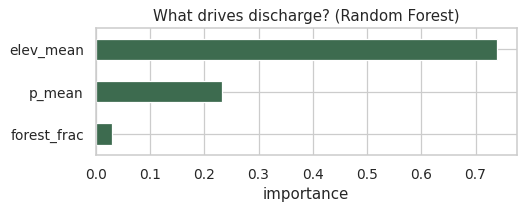

In [ ]:
# linear model: the slope (effect) of each feature
for name, coef in zip(features, lin_m.coef_):
    print(f"{name:14} slope = {coef:+.3f}")

# random forest: which features matter most for predicting discharge?
importances = pd.Series(rf_m.feature_importances_, index=features).sort_values()
importances.plot.barh(color="#3d6b4f", figsize=(6, 2.5))
plt.xlabel("importance"); plt.title("What drives discharge? (Random Forest)")
plt.tight_layout(); plt.show()

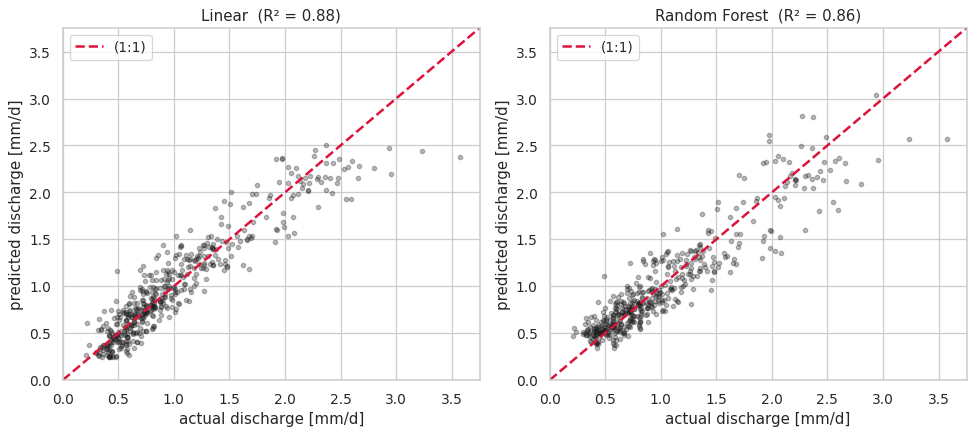

In [ ]:
# predict on the test set with both models
pred_lin = lin_m.predict(Xm_test)
pred_rf  = rf_m.predict(Xm_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, pred, name, r2 in [
    (axes[0], pred_lin, "Linear", lin_m.score(Xm_test, ym_test)),
    (axes[1], pred_rf,  "Random Forest", rf_m.score(Xm_test, ym_test)),
]:
    ax.scatter(ym_test, pred, s=12, alpha=0.3, color="k")
    lims = [0, max(ym_test.max(), pred.max()) * 1.05]
    ax.plot(lims, lims, "--", color="crimson", lw=2, label="(1:1)")
    ax.set_xlabel("actual discharge [mm/d]")
    ax.set_ylabel("predicted discharge [mm/d]")
    ax.set_xlim(lims); ax.set_ylim(lims); ax.legend()
    ax.set_title(f"{name}  (R² = {r2:.2f})")

plt.tight_layout()
plt.show()

## B5. non linear relationships

Remember in Part A we saw that **elevation and snow fraction** have a *curved* relationship: snow
fraction rises steeply with elevation at first, then levels off (Spearman beat Pearson there). A
straight line can't follow a curve — so this is the perfect place to see two more regression methods
that *can*.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.nonparametric.smoothers_lowess import lowess

# the curved relationship from Part A
Xc = df[["elev_mean"]]
yc = df["frac_snow"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.3, random_state=42)

**Method 1 — Linear (the straight line, for comparison).**

**Method 2 — Polynomial regression (parametric, but curved).** A clever trick: instead of just
`elevation`, we also feed the model `elevation²` and `elevation³`. A straight line in these extra
features becomes a *curve* in the original one. `PolynomialFeatures(3)` creates those powers, and
`make_pipeline` chains them with linear regression. It's still parametric — we just assumed a curvier
shape.

**Method 3 — LOWESS (non-parametric smoother).** LOWESS fits many tiny local lines and stitches them
into a smooth curve. It assumes no shape at all — it simply follows the data. **A note on LOWESS:** it's a *smoother* for visualizing trends, so it doesn't have a `.predict()`
> method like the other models. To get its values at new points, we use `np.interp` to read off its
> smooth curve — a small technical detail, not something students need to dwell on.

In [ ]:
# Method 1: straight line
lin_c = LinearRegression().fit(Xc_train, yc_train)

# Method 2: polynomial (degree 3) — a parametric curve
poly_c = make_pipeline(PolynomialFeatures(3), LinearRegression()).fit(Xc_train, yc_train)

print(f"Linear        R² on test = {lin_c.score(Xc_test, yc_test):.3f}")
print(f"Polynomial-3  R² on test = {poly_c.score(Xc_test, yc_test):.3f}")

Linear        R² on test = 0.874
Polynomial-3  R² on test = 0.986


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


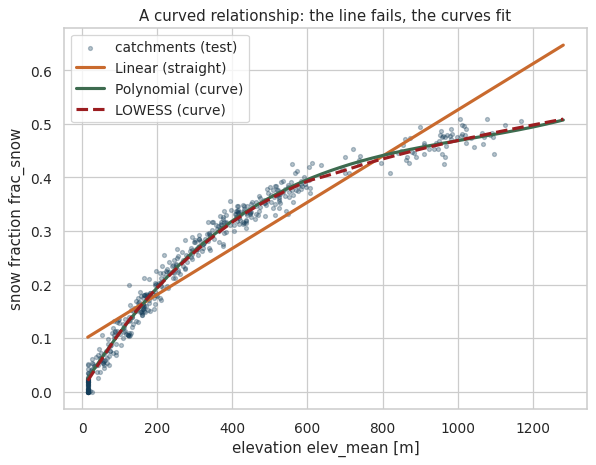

In [ ]:
import numpy as np

# a smooth elevation range for drawing the curves
elev_grid = np.linspace(df["elev_mean"].min(), df["elev_mean"].max(), 200).reshape(-1, 1)

# LOWESS: fit on training data (it returns a sorted smooth curve), then read it off
low = lowess(yc_train.values, Xc_train["elev_mean"].values, frac=0.3)
lowess_on_grid = np.interp(elev_grid.ravel(), low[:, 0], low[:, 1])

plt.figure(figsize=(7.5, 5.5))
plt.scatter(Xc_test, yc_test, s=10, alpha=0.3, color="#143d59", label="catchments (test)")
plt.plot(elev_grid, lin_c.predict(elev_grid),  color="#c96a2e", lw=2.5, label="Linear (straight)")
plt.plot(elev_grid, poly_c.predict(elev_grid), color="#3d6b4f", lw=2.5, label="Polynomial (curve)")
plt.plot(elev_grid, lowess_on_grid,            color="#9b1d20", lw=2.5, ls="--", label="LOWESS (curve)")
plt.xlabel("elevation elev_mean [m]"); plt.ylabel("snow fraction frac_snow")
plt.legend(); plt.title("A curved relationship: the line fails, the curves fit")
plt.show()

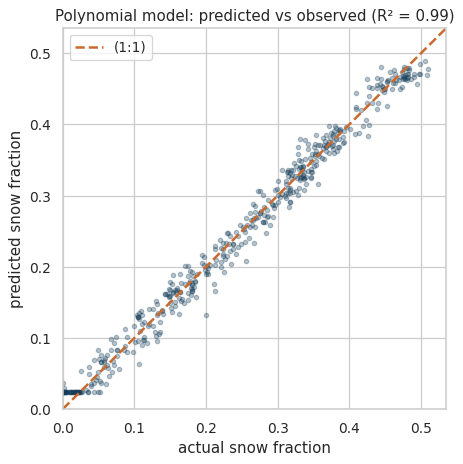

In [ ]:
#now lets test the prediction
pred_poly = poly_c.predict(Xc_test)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(yc_test, pred_poly, s=12, alpha=0.3, color="#143d59")
lims = [0, max(yc_test.max(), pred_poly.max()) * 1.05]
plt.plot(lims, lims, "--", color="#c96a2e", lw=2, label="(1:1)")
plt.xlabel("actual snow fraction"); plt.ylabel("predicted snow fraction")
plt.xlim(lims); plt.ylim(lims); plt.legend()
plt.title(f"Polynomial model: predicted vs observed (R² = {poly_c.score(Xc_test, yc_test):.2f})")
plt.show()

Task B.4

Try PolynomialFeatures(2) and PolynomialFeatures(10) instead of degree 3. Does degree 2 capture the curve? Does degree 10 do better on the test set, or does it start to overfit (wiggle)?

In [ ]:
# Your code here

## Mini-exercise: predict the runoff ratio

Now predict a different target: **`runoff_ratio`** (the fraction of rainfall that becomes streamflow).

1. Build `X` from physical features you choose (e.g. `elev_mean`, `frac_snow`,
   `forest_frac` — but *not* other hydrologic signatures like `q_mean`).
2. Split into train/test.
3. Fit a `LinearRegression` and a `RandomForestRegressor` or `KNeighborsRegressor`.
4. Compare their test R².
5. Look at the random forest's feature importances — which physical property best explains how much
   rain becomes streamflow?